# Synthetischer Datensatz — Adaption

Adaptiert das in *synthetic_data_model.ipynb* trainierte MLP an den drift-behafteten
Strom mit vier Strategien (Baseline, Passiv, Aktiv, Kombiniert);
Module `drift_adaptation.py` / `drift_detection.py`.

Die Einteilung folgt Gama et al. (2014, Abschn. 3.3.2): *blind* = rein periodisches
Nachtraining ohne Fehlerauswertung, *informed* = trigger-basiert. Als Trigger werden
alle fünf Detektoren gescreent — die vier statistischen Verfahren sowie der
Schwellwert-Detektor `RMSE`, der die Überwachung eines Performance-Indikators
(Gama Abschn. 3.2) in ihrer einfachsten Form darstellt. Die aktive und die
kombinierte Strategie werden anschließend mit dem im Screening besten Detektor
ausgewertet.

In [1]:
FORCE_RECOMPUTE = False
IS_FINAL = True

In [2]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "synthetic_data"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

In [3]:
import thesis_style as ts

TEXTWIDTH_PT = ts.TEXTWIDTH_PT
INCH_PER_PT = ts.INCH_PER_PT
fig_width_in = ts.apply_rc()

In [ ]:
import numpy as np
import pandas as pd

## Daten und Basismodell laden

In [ ]:
# --- Konstanten ---
RUN_ID = "ddf725f0"   # None -> neuestes Modell

SEED = 42

STEP_S = 600                 # Abtastung des Adaptionsstroms
STEP_TUNE_S = 3600           # groebere Abtastung fuers Tuning
DETECTORS = ("KSWIN", "ADWIN", "DDM", "EDDM", "RMSE")
N_TRIALS = {"screening": 40, "final": 60}
TUNE_WEIGHTS = (1.0, 0.1)
# Refraktaerzeit zwischen zwei Sofort-Trainings (x * T_stat); cooldown wird als cooldown_x in [0, 60] getunt
COOLDOWN_X = 30
# Update-Validierung: Nachtraining verwerfen, wenn der MSE nicht sinkt
REJECT = True
N_SEED_RUNS = 5              # Zielzahl an Laeufen mit identischer Konfiguration

rng = np.random.default_rng(SEED)

In [ ]:
from src.utils import run_registry as rr

data_store = rr.synthetic_data_store(data_dir)
model_store = rr.synthetic_model_store(model_dir)

if RUN_ID is None:
    run_id = model_store.latest_id("model")
    if run_id is None:
        raise FileNotFoundError("Kein data-Artefakt. Bitte syn_model.ipynb ausfuehren.")
else:
    run_id = RUN_ID

print(f"model run_id = {run_id}")

test_data = data_store.load("data_test", run_id=run_id, rename=True, rekey=True)
test_cfg = rr.RunConfig.from_document(test_data.attrs.get("config", test_data.attrs))

_mc = model_store.load("model", run_id=run_id, rename=True)
base_model = _mc["model"]
X_scaler = _mc["X_scaler"]
y_scaler = _mc["y_scaler"]

ledger = rr.run_ledger(work_dir)
ledger.bind("adaptation", parents={"model": test_cfg.id})
plot_store = rr.synthetic_plot_store(plot_dir, ledger=ledger)
res_store  = rr.synthetic_results_store(results_dir, ledger=ledger)

model run_id = 684487cd


KeyboardInterrupt: 

In [ ]:
STRIDE = max(1, STEP_S // 60)
stream = test_data.iloc[::STRIDE].copy()
N = len(stream)
print(f"Adaptionsstrom: {N} Punkte (STEP={STEP_S}s, STRIDE={STRIDE})")

X_free = X_scaler.transform(stream[["u1_noise_filt", "u2_noise_filt"]].to_numpy()).astype("float32")
y_free = y_scaler.transform(stream[["y_noise_filt"]].to_numpy()).ravel().astype("float32")

X_cd = X_scaler.transform(stream[["u1_cd_noise_filt", "u2_cd_noise_filt"]].to_numpy()).astype("float32")
y_cd = y_scaler.transform(stream[["y_cd_noise_filt"]].to_numpy()).ravel().astype("float32")

cd_signal = stream["cd"].to_numpy()
time_index = stream.index

## Adaptionsstrategien

In [ ]:
import tensorflow as tf
import drift_adaptation as da
from drift_adaptation import run_adaptation, StreamingDetector

## Detektor-Konfiguration (für die Informed-Adaption)

In [ ]:
import json

# Getunte Detektorparameter aus dem Detektions-Notebook als Startwerte
_det_cfg = {}
_det_results = os.path.join(results_dir, "syn_detection.json")
if os.path.exists(_det_results):
    with open(_det_results, "r", encoding="utf-8") as _f:
        _dr = json.load(_f)
    for _n in DETECTORS:
        _bp = dict(_dr.get("detectors", {}).get(_n, {}).get("best_params", {}))
        _det_cfg[_n] = {"err_threshold": _bp.pop("err_threshold", 3.0), "params": _bp}
        print(f"{_n:6s} -> {_bp}, err_threshold={_det_cfg[_n]['err_threshold']:.3f}")
else:
    print(f"{_det_results} nicht gefunden -> Standardparameter aus drift_detection.py")
    _det_cfg = {_n: {"err_threshold": 3.0, "params": {}} for _n in DETECTORS}

def make_detector(name):
    """Frischer StreamingDetector mit den im Detektions-Notebook getunten Werten."""
    c = _det_cfg.get(name, {"err_threshold": 3.0, "params": {}})
    return StreamingDetector(name, err_threshold=c["err_threshold"], **c["params"])

def detector_factory(name):
    return lambda: make_detector(name)

In [ ]:
_base_free_pred = base_model.predict(X_free, verbose=0).ravel()
_base_free_err = y_free - _base_free_pred
NORM_MEAN = float(np.mean(_base_free_err))
NORM_STD = float(np.std(_base_free_err)) or 1.0
print(f"Normierungs-Baseline: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")

Normierungs-Baseline: mean=-0.0009897, std=0.008199


## Hyperparameter-Tuning der Adaption

In [ ]:
STRIDE_TUNE = max(1, STEP_TUNE_S // 60)

_tune = test_data.iloc[::STRIDE_TUNE]
X_tune = X_scaler.transform(_tune[["u1_cd_noise_filt", "u2_cd_noise_filt"]].to_numpy()).astype("float32")
y_tune = y_scaler.transform(_tune[["y_cd_noise_filt"]].to_numpy()).ravel().astype("float32")

_, T_STAT_TUNE = da.estimate_cooldown(_tune[["w1", "w2"]], x=COOLDOWN_X)

CHUNK_TUNE = max(24, 86400 // STEP_TUNE_S)
TUNE_FIXED = dict(chunk=CHUNK_TUNE, reject=REJECT,
                  norm_mean=NORM_MEAN, norm_std=NORM_STD, seed=SEED)

best_adapt_params, studies, tune_cfgs = {}, {}, {}

def _tune_case(key, strategy, n_trials, det_name=None, enqueue=None, extra_cfg=None):
    """Tunt einen Fall und cached ihn ueber die RunConfig-Kennung."""
    tune_params = {"method": strategy, "case": key, "n_trials": n_trials,
                   "weights": list(TUNE_WEIGHTS), "step_tune_s": STEP_TUNE_S,
                   "scheme": "phase-extend", "cooldown_tuned": True,
                   **({"detector": det_name} if det_name else {}),
                   **(extra_cfg or {}),
                   **{k: TUNE_FIXED[k] for k in sorted(TUNE_FIXED)}}
    tune_cfgs[key] = test_cfg.compose(tuning=tune_params)
    if (model_store.exists("adapt_tuning", tune_cfgs[key], rekey=True)
            and not FORCE_RECOMPUTE):
        best_adapt_params[key] = model_store.load("adapt_tuning", tune_cfgs[key], rekey=True)
        print(f"{key:18s} aus Cache")
        return
    tf.keras.utils.set_random_seed(SEED)
    _fac = detector_factory(det_name) if det_name else None
    _study, _ = da.tune_adaptation(strategy, base_model, X_tune, y_tune,
                                   fixed=TUNE_FIXED, detector_factory=_fac,
                                   n_trials=n_trials, weights=TUNE_WEIGHTS,
                                   seed=SEED, enqueue=enqueue, t_stat=T_STAT_TUNE)
    studies[key] = _study
    best_adapt_params[key] = da.decode_adapt_params(_study.best_params)
    _a = _study.best_trial.user_attrs
    print(f"{key:18s} score={_study.best_value:.3f} | rmse={_a['rmse']:.3f} "
          f"n_train={_a['n_train']:3d} n_detect={_a['n_detect']:3d}")
    model_store.save(best_adapt_params[key], "adapt_tuning", tune_cfgs[key])

# --- Passive Strategie (detektorfrei, finale Konfiguration direkt) ---
_tune_case("blind", "blind", N_TRIALS["final"])

# --- Screening: informierte Strategie je Detektor, reduziertes Budget ---
print(f"\nDetektor-Screening ({N_TRIALS['screening']} Trials je Detektor)")
for _det in DETECTORS:
    # Warmstart mit dem Optimum aus dem Detektions-Notebook
    _c = _det_cfg.get(_det, {"err_threshold": 3.0, "params": {}})
    _warm = {f"det_{k}": v for k, v in _c["params"].items() if k != "seed"}
    if _det in ("DDM", "EDDM"):
        _warm["det_err_threshold"] = _c["err_threshold"]
    _tune_case(f"informed@{_det}", "informed", N_TRIALS["screening"],
               det_name=_det, enqueue=[{**_warm}] if _warm else None)

In [ ]:
# Gegenpruefung des Screenings auf dem voll aufgeloesten Strom. Ausgewaehlt wird
# der Detektor mit dem kleinsten RMSE eines vollstaendigen Adaptionslaufs; das
# Tuning laeuft auf einem groeber abgetasteten Strom, die Uebertragung der
# Konfiguration ist daher eine Extrapolation und muss geprueft werden.
_RESCALE = STRIDE_TUNE / STRIDE
CHUNK = max(24, 86400 // STEP_S)
_BASE_CFG = dict(chunk=CHUNK, reject=REJECT, norm_mean=NORM_MEAN, norm_std=NORM_STD)
COOLDOWN, T_stat = da.estimate_cooldown(stream[["w1", "w2"]], x=COOLDOWN_X)

_scr_cfg = test_cfg.compose(screening={
    "detectors": sorted(DETECTORS), "step_s": STEP_S, "cooldown_x": COOLDOWN_X,
    "rescale": _RESCALE, "reject": REJECT,
    "params": {d: da.encode_adapt_params(best_adapt_params[f"informed@{d}"])
               for d in DETECTORS}})

if model_store.exists("adapt_screening", _scr_cfg, rekey=True) and not FORCE_RECOMPUTE:
    screening = model_store.load("adapt_screening", _scr_cfg, rekey=True)
    print("Screening aus Cache")
else:
    screening = {}
    for _det in DETECTORS:
        _key = f"informed@{_det}"
        _, _tab = da.crosscheck_candidates(
            base_model, X_cd, y_cd,
            best_params={"informed": best_adapt_params[_key]}, fixed=_BASE_CFG,
            t_stat=T_stat, detector_factory=detector_factory(_det),
            study=None, top_k=0, rescale=_RESCALE, mode="informed", seed=SEED,
            verbose=False)
        screening[_det] = _tab["tpe_best"]
        print(f"{_det:6s} RMSE={_tab['tpe_best']['rmse']:.4f}  "
            f"n_train={_tab['tpe_best']['n_train']}")

    model_store.save(screening, "adapt_screening", _scr_cfg)

BEST_DETECTOR = min(screening, key=lambda d: screening[d]["rmse"])
print(f"\nGewaehlter Detektor: {BEST_DETECTOR} "
      f"(RMSE={screening[BEST_DETECTOR]['rmse']:.4f})")

screening_table = pd.DataFrame(
    {d: {"rmse": v["rmse"], "n_train": v["n_train"]} for d, v in screening.items()}).T

KSWIN  RMSE=0.7743  n_train=171


c:\git\process_optimization_concept_drift\venv_311\Lib\site-packages\frouros\detectors\concept_drift\streaming\window_based\adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (


ADWIN  RMSE=1.2742  n_train=178
DDM    RMSE=1.5379  n_train=40
EDDM   RMSE=1.0416  n_train=197
RMSE   RMSE=0.8101  n_train=264

Gewaehlter Detektor: KSWIN (RMSE=0.7743)


In [ ]:
# Der gewaehlte Detektor wird mit vollem Budget nachgetunt (Warmstart mit dem
# Screening-Optimum), danach die kombinierte Strategie mit demselben Detektor
# (Warmstart mit der Vereinigung der Einzeloptima).
_scr = best_adapt_params[f"informed@{BEST_DETECTOR}"]
_tune_case("informed", "informed", N_TRIALS["final"], det_name=BEST_DETECTOR,
           enqueue=[da.encode_adapt_params(_scr)])

_bl, _inf = best_adapt_params["blind"], best_adapt_params["informed"]
_tune_case("combined", "combined", N_TRIALS["final"], det_name=BEST_DETECTOR,
           enqueue=[da.encode_adapt_params({**_bl, **_inf}),
                    da.encode_adapt_params({**_inf, **_bl})])

# --- Gegenpruefung auf voller Aufloesung -------------------------------------
# Eigener Cache-Fall: der Crosscheck darf NICHT nach "adapt_tuning" zurueck-
# schreiben, sonst laedt _tune_case beim naechsten Lauf sein eigenes Ergebnis
# und die Gegenpruefung startet von einem anderen Kandidatensatz.
# Der Schluessel haengt an den TPE-Optima (= Eingang), damit er inhalts-
# adressiert und ueber Laeufe hinweg stabil ist.
_CC_KEYS = ("blind", "informed", "combined")
_cc_cfg = test_cfg.compose(crosscheck={
    "detector": BEST_DETECTOR,
    "step_s": STEP_S,
    "cooldown_x": COOLDOWN_X,
    "rescale": float(_RESCALE),
    "reject": REJECT,
    "chunk": CHUNK,
    "top_k": 3,
    "tpe": {k: da.encode_adapt_params(best_adapt_params[k]) for k in _CC_KEYS},
})

if model_store.exists("adapt_crosscheck", _cc_cfg, rekey=True) and not FORCE_RECOMPUTE:
    best_adapt_params.update(model_store.load("adapt_crosscheck", _cc_cfg, rekey=True))
    print(f"Crosscheck aus Cache ({BEST_DETECTOR})")
    for _m in _CC_KEYS:
        print(f"  {_m:9s} {best_adapt_params[_m]}")
else:
    # informed zuerst, da der union-Kandidat der kombinierten Strategie dessen
    # Optimum nutzt.
    _extra = {"informed": {"combined_cfg": dict(best_adapt_params["combined"]),
                           "screening_cfg": dict(_scr)}}
    for _m in ("informed", "combined"):
        print(f"--- {_m} ({BEST_DETECTOR}) ---")
        best_adapt_params[_m], _ = da.crosscheck_candidates(
            base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
            t_stat=T_stat, detector_factory=detector_factory(BEST_DETECTOR),
            study=studies.get(_m), rescale=_RESCALE, mode=_m, seed=SEED,
            extra=_extra.get(_m))

    # Die passive Strategie ebenfalls gegenpruefen (blind_period wird mitskaliert)
    print("--- blind ---")
    best_adapt_params["blind"], _ = da.crosscheck_candidates(
        base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
        t_stat=T_stat, detector_factory=None, study=studies.get("blind"),
        rescale=_RESCALE, mode="blind", seed=SEED)

    model_store.save({k: best_adapt_params[k] for k in _CC_KEYS},
                     "adapt_crosscheck", _cc_cfg)

[I 2026-07-22 14:52:55,133] A new study created in memory with name: no-name-13010805-7ed9-4d8b-8398-9c157b429ce3
[I 2026-07-22 14:54:02,461] Trial 0 finished with value: 0.5785568748531623 and parameters: {'lr': 0.0045671439915963225, 'epochs': 18, 'freeze': 'TFF', 'reset': False, 'window_prev': 87, 'window_post': 83, 'cooldown_x': 21.694193662195154, 'det_min_num_instances': 224, 'det_alpha': 1.2200916399835832e-05, 'det_num_test_instances': 83}. Best is trial 0 with value: 0.5785568748531623.
[I 2026-07-22 14:55:13,967] Trial 1 finished with value: 0.9547551742482429 and parameters: {'lr': 0.000653180902960385, 'epochs': 20, 'freeze': 'TFF', 'reset': False, 'window_prev': 10, 'window_post': 88, 'cooldown_x': 36.06690070459253, 'det_min_num_instances': 298, 'det_alpha': 1.1916299962955147e-06, 'det_num_test_instances': 146}. Best is trial 0 with value: 0.5785568748531623.
[I 2026-07-22 14:55:34,295] Trial 2 finished with value: 1.0167123287671234 and parameters: {'lr': 0.006478450641

informed           score=0.515 | rmse=0.803 n_train=125 n_detect= 74


[I 2026-07-22 15:41:26,651] A new study created in memory with name: no-name-6187f87c-afb9-48ab-b96d-8692822f8f1e
[I 2026-07-22 15:43:10,378] Trial 0 finished with value: 0.48379762655787895 and parameters: {'lr': 0.012526554363288386, 'epochs': 17, 'freeze': 'TFF', 'reset': False, 'blind_window': 59, 'blind_period': 70, 'window_prev': 95, 'window_post': 45, 'cooldown_x': 15.53053625991702, 'det_min_num_instances': 99, 'det_alpha': 4.488265435357362e-05, 'det_num_test_instances': 31}. Best is trial 0 with value: 0.48379762655787895.
[I 2026-07-22 15:44:57,654] Trial 1 finished with value: 0.4837201500952946 and parameters: {'lr': 0.007207606954075903, 'epochs': 19, 'freeze': 'TFF', 'reset': False, 'blind_window': 59, 'blind_period': 70, 'window_prev': 95, 'window_post': 45, 'cooldown_x': 15.53053625991702, 'det_min_num_instances': 99, 'det_alpha': 4.488265435357362e-05, 'det_num_test_instances': 31}. Best is trial 1 with value: 0.4837201500952946.
[I 2026-07-22 15:45:52,321] Trial 2 fi

combined           score=0.484 | rmse=0.714 n_train=206 n_detect= 74
--- informed (KSWIN) ---
tpe_best     RMSE=0.8416  n_train=129  n_detect=87
trial_42     RMSE=0.8416  n_train=129  n_detect=87
trial_45     RMSE=0.9789  n_train=128  n_detect=82
trial_21     RMSE=0.9924  n_train=154  n_detect=143
combined_cfg RMSE=0.7711  n_train=132  n_detect=87
screening_cfg RMSE=0.7743  n_train=171  n_detect=38
uebernommen: combined_cfg (RMSE=0.771)
--- combined (KSWIN) ---
tpe_best     RMSE=0.6943  n_train=206  n_detect=87
union        RMSE=0.6943  n_train=206  n_detect=87
trial_1      RMSE=0.6943  n_train=206  n_detect=87
trial_0      RMSE=0.7678  n_train=204  n_detect=87
trial_30     RMSE=0.8663  n_train=362  n_detect=106
uebernommen: tpe_best (RMSE=0.694)
--- blind ---
tpe_best     RMSE=0.6813  n_train=121  n_detect=0
trial_53     RMSE=0.6813  n_train=121  n_detect=0
trial_57     RMSE=0.6690  n_train=121  n_detect=0
trial_55     RMSE=0.7345  n_train=121  n_detect=0
uebernommen: trial_57 (RMSE=0

## Adaption ausführen

In [ ]:
ADAPT_CFG = dict(
    lr=3e-3, epochs=9, freeze=(True, False, False), reset=False,
    blind_window=44, blind_period=CHUNK,        # Default: taegliches Nachtraining
    window_prev=max(1, 300 // STRIDE), window_post=max(1, 300 // STRIDE),
    reject=REJECT, chunk=CHUNK, norm_mean=NORM_MEAN, norm_std=NORM_STD,
)
STRATEGIES = ("baseline", "blind", "informed", "combined")

# cooldown_x -> cooldown (Vielfaches der stationaeren Phasendauer der Zielaufloesung);
# fuer baseline/blind ohne Wirkung (kein cooldown_x im Parametersatz).
applied_cfg = {s: da.resolve_cooldown(
                   {**ADAPT_CFG, **da.scale_adapt_params(best_adapt_params.get(s, {}), _RESCALE)},
                   T_stat)
               for s in STRATEGIES}
print(f"T_stat ~ {T_stat:.0f} Punkte (~{T_stat * STEP_S / 3600:.1f} h) | "
      f"Detektor = {BEST_DETECTOR} | cooldown je Strategie getunt")

adapt_cfg = test_cfg.compose(adaptation={
    "step_s": STEP_S, "detector": BEST_DETECTOR, "scheme": "phase-extend",
    "cooldown_tuned": True, "screening": sorted(DETECTORS),
    "applied": {k: {kk: v for kk, v in applied_cfg[k].items()
                    if kk not in ("norm_mean", "norm_std")} for k in STRATEGIES}})

_adapt_from_cache = model_store.exists("adaptation", adapt_cfg, rekey=True) and not FORCE_RECOMPUTE
if _adapt_from_cache:
    results = model_store.load("adaptation", adapt_cfg, rename=True, rekey=True)
else:
    results = {}
    for _name in STRATEGIES:
        tf.keras.utils.set_random_seed(SEED)
        _detector = make_detector(BEST_DETECTOR) if _name in ("informed", "combined") else None
        _detector, _cfg = da.apply_det_params(_detector, applied_cfg[_name])
        print(f"Strategie '{_name}' ...")
        results[_name] = run_adaptation(base_model, X_cd, y_cd, mode=_name,
                                        detector=_detector, seed=SEED, verbose=True, **_cfg)
        print(f"  -> {len(results[_name]['train_steps'])} Nachtrainings, "
              f"{len(results[_name]['detect_steps'])} Detektionen")
    model_store.save(results, "adaptation", adapt_cfg)

T_stat ~ 43 Punkte (~7.1 h) | Detektor = KSWIN | cooldown je Strategie getunt
Strategie 'baseline' ...
  baseline: 144/52560 Punkte, 0 Nachtrainings
  baseline: 7344/52560 Punkte, 0 Nachtrainings
  baseline: 14544/52560 Punkte, 0 Nachtrainings
  baseline: 21744/52560 Punkte, 0 Nachtrainings
  baseline: 28944/52560 Punkte, 0 Nachtrainings
  baseline: 36144/52560 Punkte, 0 Nachtrainings
  baseline: 43344/52560 Punkte, 0 Nachtrainings
  baseline: 50544/52560 Punkte, 0 Nachtrainings
  -> 0 Nachtrainings, 0 Detektionen
Strategie 'blind' ...
  blind: 144/52560 Punkte, 0 Nachtrainings
  blind: 7344/52560 Punkte, 17 Nachtrainings
  blind: 14544/52560 Punkte, 33 Nachtrainings
  blind: 21744/52560 Punkte, 50 Nachtrainings
  blind: 28944/52560 Punkte, 67 Nachtrainings
  blind: 36144/52560 Punkte, 83 Nachtrainings
  blind: 43344/52560 Punkte, 100 Nachtrainings
  blind: 50544/52560 Punkte, 117 Nachtrainings
  -> 121 Nachtrainings, 0 Detektionen
Strategie 'informed' ...
  informed: 144/52560 Punkte,

## Vergleich der Adaptionsstrategien

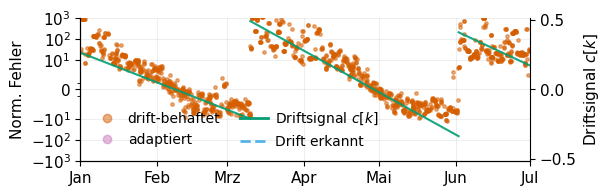

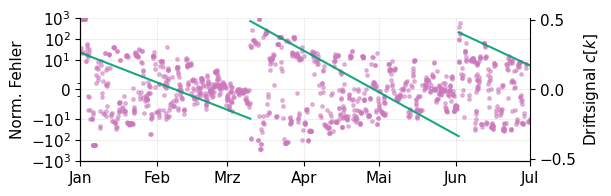

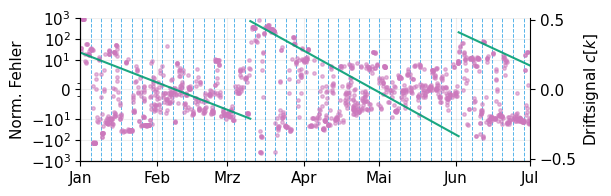

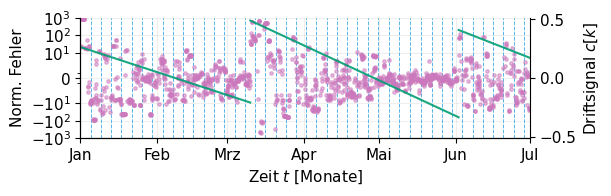

In [ ]:
import locale
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

try:
    locale.setlocale(locale.LC_TIME, "de_DE.UTF-8")
except locale.Error:
    pass

PLOT_END = pd.Timestamp("1970-07-01")
_mask_plot = time_index <= PLOT_END
t_plot = time_index[_mask_plot]
cd_plot = cd_signal[_mask_plot]
n_plot = len(t_plot)

ALPHA, S, FRAC = 0.5, 6, 0.05
C_ERR, C_DRIFT, C_DET = ts.C["drift_afflicted"], ts.C["drift_signal"], ts.C["detection"]

PANELS = [("baseline", "Baseline"), ("blind", "Blind"),
          ("informed", "Informed"), ("combined", "Combined")]

def align_zero(ax_left, ax_right):
    '''0 beider Ordinaten auf gleiche Hoehe (wie in den uebrigen Notebooks).'''
    ax_left.figure.canvas.draw()
    lims = [ax_left.get_ylim(), ax_right.get_ylim()]
    fracs = [(-lo / (hi - lo) if hi != lo else 0.5) for lo, hi in lims]
    r = min(max(max(fracs), 1e-3), 1 - 1e-3)
    for ax, (lo, hi) in zip((ax_left, ax_right), lims):
        span = max(hi / (1 - r), -lo / r)
        ax.set_ylim(-r * span, (1 - r) * span)

cut = np.flatnonzero(np.diff(cd_plot) > 0) + 1
for k, (key, title) in enumerate(PANELS):
    err_norm = results[key]["errors_norm"][_mask_plot]
    detect = [d for d in results[key]["detect_steps"] if d < n_plot]

    fig, ax = plt.subplots(figsize=(fig_width_in, fig_width_in * 0.33))
    m = rng.random(n_plot) < FRAC
    c_err = ts.C["drift_afflicted"] if key == "baseline" else ts.C["adapted"]
    ax.scatter(t_plot[m], err_norm[m], color=c_err, s=S, alpha=ALPHA,
               zorder=3, rasterized=True)

    ax2 = ax.twinx()
    for i, (a, b) in enumerate(zip(np.r_[0, cut], np.r_[cut, len(cd_plot)])):
        ax2.plot(t_plot[a:b], cd_plot[a:b], **ts.line("drift_signal", linewidth=1.5))
    ax2.set_ylabel("Driftsignal $c[k]$")
    ax2.spines["right"].set_visible(True)
    ax2.spines["top"].set_visible(False)
    ax2.set_ylim(-1.05*abs(cd_plot).max(), 1.05*abs(cd_plot).max())

    for d in detect:
        ax.axvline(t_plot[d], zorder=2, **ts.vline("detection", lw=0.7, linestyle="--"))

    ax.set_yscale("symlog", linthresh=3, linscale=0.8)
    ax.set_ylim(-1e3, 1e3)
    ax.set_yticks([-1e3, -1e2, -1e1, 0, 1e1, 1e2, 1e3])
    ax.set_yticklabels([r"$-10^3$", r"$-10^2$", r"$-10^1$", r"$0$",
                    r"$10^1$", r"$10^2$", r"$10^3$"])
    ax.set_ylabel("Norm. Fehler")
    ax.margins(x=0)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    if k == len(PANELS) - 1:
        ax.set_xlabel("Zeit $t$ [Monate]")

    if k == 0:
        handles = [Line2D([0], [0], marker="o", linestyle="", color=ts.C["drift_afflicted"],
                          alpha=ALPHA, label="drift-behaftet"),
                   Line2D([0], [0], marker="o", linestyle="", color=ts.C["adapted"],
                          alpha=ALPHA, label="adaptiert"),
                   Line2D([0], [0], color=C_DRIFT, label="Driftsignal $c[k]$"),
                   Line2D([0], [0], color=C_DET, linestyle="--", label="Drift erkannt")]
        ax.legend(handles=handles, loc="lower left",
                  ncol=2, frameon=False, columnspacing=1.4, handletextpad=0.5)

    fig.tight_layout()
    if not _adapt_from_cache:
        plot_store.save_figure(fig, f"synthetic_data_adaptation_{key}", adapt_cfg,
                               final=IS_FINAL, savefig_kwargs={"dpi": 300},
                               archive_kwargs={"dpi": 300})
    plt.show()

## RMSE-Verlauf der Strategien

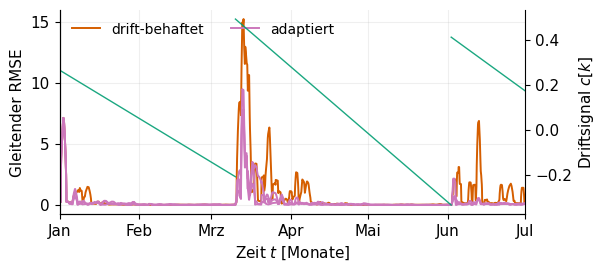

In [ ]:
WIN = max(10, 86400 // STEP_S)

fig, ax = plt.subplots(figsize=(fig_width_in, fig_width_in * 0.45))

_adapt_labeled = False
for key, title in PANELS:
    e = pd.Series(results[key]["errors"], index=time_index)
    rmse_roll = np.sqrt((e ** 2).rolling(WIN, min_periods=1).mean())
    rmse_roll = rmse_roll[rmse_roll.index <= PLOT_END]
    if key == "baseline":
        _col, _lab = ts.C["drift_afflicted"], "drift-behaftet"
    else:
        _col = ts.C["adapted"]
        _lab = "adaptiert" if not _adapt_labeled else None
        _adapt_labeled = True
    ax.plot(rmse_roll.index, rmse_roll.values, color=_col, linewidth=1.4, label=_lab)

ax2 = ax.twinx()
for i, (a, b) in enumerate(zip(np.r_[0, cut], np.r_[cut, len(cd_plot)])):
    ax2.plot(t_plot[a:b], cd_plot[a:b], **ts.line("drift_signal", linewidth=1.0))
ax2.set_ylabel("Driftsignal $c[k]$")
ax2.spines["right"].set_visible(True)
ax2.spines["top"].set_visible(False)

ax.set_ylabel("Gleitender RMSE")
ax.set_xlabel("Zeit $t$ [Monate]")
ax.margins(x=0)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", ncol=2, frameon=False)
fig.tight_layout()
plt.show()

## Numerische Auswertung

In [ ]:
def _strategy_stats(res, c, rmse_baseline):
    e = np.asarray(res["errors"], float)
    c = np.asarray(c, float)
    rmse = float(np.sqrt(np.mean(e ** 2)))
    return dict(
        rmse=rmse,
        bias=float(np.mean(e)),
        sigma=float(np.std(e)),
        corr_abs=float(np.corrcoef(np.abs(e), np.abs(c))[0, 1]),
        n_train=int(len(res["train_steps"])),
        n_detect=int(len(res["detect_steps"])),
        n_reject=int(len(res.get("reject_steps", []))),
        rmse_improvement=float(1.0 - rmse / rmse_baseline) if rmse_baseline else 0.0,
    )

_rmse_base = float(np.sqrt(np.mean(np.asarray(results["baseline"]["errors"], float) ** 2)))
stats = pd.DataFrame({k: _strategy_stats(results[k], cd_signal, _rmse_base)
                      for k, _ in PANELS}).T
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(stats.to_string())

           rmse    bias  sigma  corr_abs  n_train  n_detect  n_reject  rmse_improvement
baseline  1.663  0.4007  1.614    0.3724        0         0         0                 0
blind     0.669 0.05816 0.6665    0.2192      121         0         0            0.5978
informed 0.7711  0.0769 0.7673    0.2685      132        87         2            0.5364
combined 0.6943 0.05874 0.6918    0.2305      206        87         6            0.5826


## Seed-Robustheit

In [ ]:
from glob import glob as _glob

_case = "adaptation_seeds"

# 1) Archiv durchsuchen: Laeufe mit derselben Konfiguration, aber anderem Seed
#    (Vergleich ueber die RunConfig-Kennung ohne seed_eval-Sektion)
seed_results = {SEED: results}   # Haupt-Seed aus der Adaptions-Zelle
for _sc_path in sorted(_glob(os.path.join(model_dir, f"{model_store.prefix}_{_case}_*.json"))):
    with open(_sc_path, encoding="utf-8") as _f:
        _sc = json.load(_f)
    if _sc.get("case") != _case:
        continue
    _doc = dict(_sc["config"])
    _seed_sec = _doc.pop("seed_eval", None) or {}
    _seed = _seed_sec.get("seed")
    if _seed is None or _seed in seed_results:
        continue
    if rr.RunConfig.from_document(_doc).id != adapt_cfg.id:
        continue   # andere Adaptions-Konfiguration
    seed_results[_seed] = model_store.load(_case, run_id=_sc["id"], rename=True)
    print(f"Seed {_seed}: aus Archiv geladen")

# 2) Fehlende Laeufe mit Zufalls-Seeds auffuellen
_rng_seed = np.random.default_rng(SEED)
_seeds_added = False
while len(seed_results) < N_SEED_RUNS:
    _seed = int(_rng_seed.integers(1, 2**10 - 1))
    if _seed in seed_results:
        continue
    _cfg_seed = adapt_cfg.compose(seed_eval={"seed": _seed})
    _res = {}
    for _name in STRATEGIES:
        tf.keras.utils.set_random_seed(_seed)
        _det = make_detector(BEST_DETECTOR) if _name in ("informed", "combined") else None
        _det, _cfg = da.apply_det_params(_det, applied_cfg[_name])
        print(f"Seed {_seed}, Strategie '{_name}' ...")
        _res[_name] = run_adaptation(base_model, X_cd, y_cd, mode=_name,
                                     detector=_det, seed=_seed, **_cfg)
    model_store.save(_res, _case, _cfg_seed)
    seed_results[_seed] = _res
    _seeds_added = True

# 3) Kombinierte Auswertung ueber alle Seeds
SEEDS = tuple(seed_results)
seed_rmse = pd.DataFrame(
    {_sd: {s: float(np.sqrt(np.mean(np.asarray(_r[s]["errors"], float) ** 2)))
           for s in STRATEGIES}
     for _sd, _r in seed_results.items()})
seed_rmse["mean"] = seed_rmse[list(seed_results)].mean(axis=1)
seed_rmse["std"] = seed_rmse[list(seed_results)].std(axis=1)
print(f"\n{len(seed_results)} Laeufe (Seeds: {list(seed_results)})")
print(seed_rmse.to_string(float_format=lambda v: f"{v:.3f}"))

## Zusätzlicher Plot zu mehreren Seeds

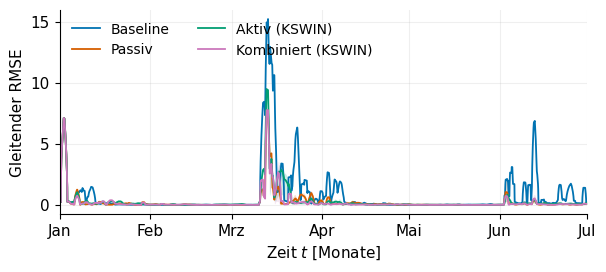

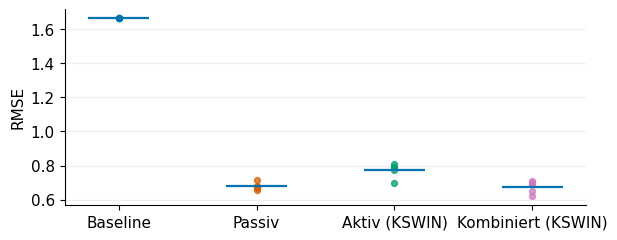

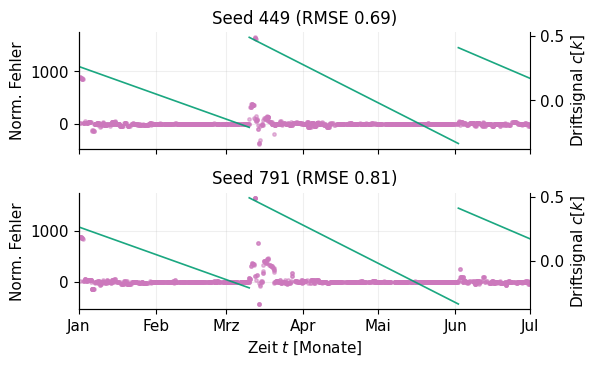

In [ ]:
_labels = {"baseline": "Baseline", "blind": "Passiv",
           "informed": f"Aktiv ({BEST_DETECTOR})",
           "combined": f"Kombiniert ({BEST_DETECTOR})"}

# (a) Gleitender RMSE: Mittelwert und Min-Max-Band ueber die Seeds
fig, ax = plt.subplots(figsize=(fig_width_in, fig_width_in * 0.45))
for _name in STRATEGIES:
    _rolls = []
    for _r in seed_results.values():
        _e = pd.Series(_r[_name]["errors"], index=time_index)
        _roll = np.sqrt((_e ** 2).rolling(WIN, min_periods=1).mean())
        _rolls.append(_roll[_roll.index <= PLOT_END])
    _m = pd.concat(_rolls, axis=1)
    _line, = ax.plot(_m.index, _m.mean(axis=1), linewidth=1.3, label=_labels[_name])
    ax.fill_between(_m.index, _m.min(axis=1), _m.max(axis=1),
                    color=_line.get_color(), alpha=0.18, linewidth=0)
ax.set_ylabel("Gleitender RMSE")
ax.set_xlabel("Zeit $t$ [Monate]")
ax.margins(x=0)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", ncol=2, frameon=False)
fig.tight_layout()
if not _adapt_from_cache or _seeds_added:
    plot_store.save_figure(fig, "synthetic_data_adaptation_seed_band", adapt_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
plt.show()

# (b) RMSE je Seed und Strategie (Punkte) mit Mittelwertstrich
fig, ax = plt.subplots(figsize=(fig_width_in, fig_width_in * 0.4))
for _k, _name in enumerate(STRATEGIES):
    _vals = seed_rmse.loc[_name, list(seed_results)].to_numpy(float)
    ax.scatter([_k] * len(_vals), _vals, s=18, alpha=0.75, zorder=3)
    ax.hlines(_vals.mean(), _k - 0.22, _k + 0.22, linewidth=1.6, zorder=4)
ax.set_xticks(range(len(STRATEGIES)))
ax.set_xticklabels([_labels[s] for s in STRATEGIES])
ax.set_ylabel("RMSE")
ax.grid(True, axis="y", alpha=0.2)
fig.tight_layout()
if not _adapt_from_cache or _seeds_added:
    plot_store.save_figure(fig, "synthetic_data_adaptation_seed_rmse", adapt_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
plt.show()

# (c) Aktive Strategie: bester vs. schlechtester Seed (Instabilitaets-Illustration)
_inf = seed_rmse.loc["informed", list(seed_results)]
_best_seed, _worst_seed = _inf.idxmin(), _inf.idxmax()
fig, axes = plt.subplots(2, 1, figsize=(fig_width_in, fig_width_in * 0.6), sharex=True)
for _ax, _sd in zip(axes, (_best_seed, _worst_seed)):
    _en = np.asarray(seed_results[_sd]["informed"]["errors_norm"])[_mask_plot]
    _mm = rng.random(n_plot) < FRAC
    _ax.scatter(t_plot[_mm], _en[_mm], color=ts.C["adapted"], s=S, alpha=ALPHA,
                zorder=3, rasterized=True)
    _ax2 = _ax.twinx()
    for _a, _b in zip(np.r_[0, cut], np.r_[cut, len(cd_plot)]):
        _ax2.plot(t_plot[_a:_b], cd_plot[_a:_b], **ts.line("drift_signal", linewidth=1.2))
    _ax2.set_ylabel("Driftsignal $c[k]$")
    _ax2.spines["right"].set_visible(True)
    _ax2.spines["top"].set_visible(False)
    _ax.set_ylabel("Norm. Fehler")
    _ax.margins(x=0)
    _ax.grid(True, alpha=0.2)
    _ax.set_title(f"Seed {_sd} (RMSE {_inf[_sd]:.2f})")
axes[-1].set_xlabel("Zeit $t$ [Monate]")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.tight_layout()
if not _adapt_from_cache or _seeds_added:
    plot_store.save_figure(fig, "synthetic_data_adaptation_informed_seeds", adapt_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
plt.show()

## Ergebnisse speichern

In [ ]:
from src.utils import results_export as rx

_keys = [(k, k, "int" if k in ("n_train", "n_detect", "n_reject") else "num")
         for k in ["rmse", "bias", "sigma", "corr_abs",
                   "n_train", "n_detect", "n_reject", "rmse_improvement"]]

doc = (rx.ResultDoc()
   .integer("n_samples", N)
   .integer("step_seconds", STEP_S)
   .set("detectors_screened", list(DETECTORS))
   .set("informed_detector", BEST_DETECTOR)
   .set("screening", {d: {"rmse": float(v["rmse"]), "n_train": int(v["n_train"])}
                      for d, v in screening.items()})
   .set("config", ADAPT_CFG)
   .set("tuning", {
       "step_tune_seconds": int(STEP_TUNE_S),
       "n_trials": N_TRIALS,
       "weights": list(TUNE_WEIGHTS),
       "best_params": best_adapt_params,
   })
   .set("cooldown", {"tuned": True, "x_range": [0.0, 60.0], "t_stat_points": float(T_stat)})
   .set("applied_config", applied_cfg)
   .stats(stats, _keys, into="strategies", rows=[k for k, _ in PANELS]))

if "seed_rmse" in dir():
    doc.set("seed_eval", {
        "seeds": [int(s) for s in SEEDS],
        "rmse": {s: {"mean": float(seed_rmse.loc[s, "mean"]),
                     "std": float(seed_rmse.loc[s, "std"])} for s in STRATEGIES},
    })

doc.save(res_store, "adaptation", adapt_cfg, final=IS_FINAL)

In [ ]:
from src.utils import latex_export as lx

mx = lx.MacroExport("Automatisch erzeugt aus syn_adaptation.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant)")
mx.param("paramTa",     STEP_S,      unit=r"\second")
mx.param("paramTaTune", STEP_TUNE_S, unit=r"\second")
mx.param("paramNPoints", N)
mx.param("paramChunk",   CHUNK)

mx.comment("Ergebnisse (Adaptionskennzahlen je Strategie)")
_name_map = {"baseline": "Baseline", "blind": "Blind",
             "informed": "Informed", "combined": "Combined"}
_keys = [("rmse", "Rmse", 3), ("bias", "Bias", 3), ("sigma", "Sigma", 3),
         ("corr_abs", "CorrAbs", 2), ("rmse_improvement", "Improve", 3)]
for k, _ in PANELS:
    m = _name_map[k]
    for col, suf, nd in _keys:
        mx.num(f"adapt{m}{suf}", stats.loc[k, col], nd)
    mx.integer(f"adapt{m}NTrain",  stats.loc[k, "n_train"])
    mx.integer(f"adapt{m}NDetect", stats.loc[k, "n_detect"])

mx.save(res_store, "adaptation", adapt_cfg, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\syn_adaptation.tex

% automatisch erzeugt aus syn_adaptation.ipynb - nicht manuell editieren
\newcommand{\adaptBaselineRmse}{1{,}663}
\newcommand{\adaptBaselineBias}{0{,}401}
\newcommand{\adaptBaselineSigma}{1{,}614}
\newcommand{\adaptBaselineCorrAbs}{0{,}37}
\newcommand{\adaptBaselineImprove}{0{,}000}
\newcommand{\adaptBaselineNTrain}{0}
\newcommand{\adaptBaselineNDetect}{0}
\newcommand{\adaptBlindRmse}{0{,}669}
\newcommand{\adaptBlindBias}{0{,}058}
\newcommand{\adaptBlindSigma}{0{,}666}
\newcommand{\adaptBlindCorrAbs}{0{,}22}
\newcommand{\adaptBlindImprove}{0{,}598}
\newcommand{\adaptBlindNTrain}{121}
\newcommand{\adaptBlindNDetect}{0}
\newcommand{\adaptInformedRmse}{0{,}771}
\newcommand{\adaptInformedBias}{0{,}077}
\newcommand{\adaptInformedSigma}{0{,}767}
\newcommand{\adaptInformedCorrAbs}{0{,}27}
\newcommand{\adaptInformedImprove}{0{,}536}
\newcommand{\adaptInformedNTrain}{132}
\newcommand{\adaptInformedNDetect}{87}